## 1. Загрузка данных

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [23]:
data = pd.read_csv("AmesHousing.csv")
data.drop(columns=["Order"], inplace=True)
data.drop(columns=["PID"], inplace=True)
print(f"Размерность DataFrame: {data.shape}")
data.head()

Размерность DataFrame: (2930, 80)


,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2. Очистка пропусков
Категориальные: заменяем NaN на "None"
Числовые: заменяем на 0, где NaN означает отсутствие подвала/гаража
Lot Frontage: заполняем медианой по соседству
Очищаем другие пропуски, заполняя 0, None или модой

In [24]:
for column in ["Alley", "Pool QC", "Fence", "Misc Feature", "Fireplace Qu","Garage Type", "Garage Finish",
               "Garage Qual", "Garage Cond", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure", "BsmtFin Type 1", "BsmtFin Type 2"]:
    data[column] = data[column].fillna("None")

In [25]:
for column in ["Bsmt Full Bath", "Bsmt Half Bath", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
               "Total Bsmt SF", "Garage Area", "Garage Cars"]:
    data[column] = data[column].fillna(0)

In [42]:
data["Lot Frontage"] = data.groupby("Neighborhood")["Lot Frontage"].transform(lambda x: x.fillna(x.median()))
data["Lot Frontage"] = data["Lot Frontage"].fillna(data["Lot Frontage"].median())

In [27]:
data["Mas Vnr Area"] = data["Mas Vnr Area"].fillna(0)
data["Mas Vnr Type"] = data["Mas Vnr Type"].fillna("None")
data["Electrical"] = data["Electrical"].fillna(data["Electrical"].mode()[0])

for col in data.columns[data.isnull().any()]:
    if data[col].dtype == "object":
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

In [28]:
print(f"Пропусков после очистки: {data.isnull().sum().sum()}")

Пропусков после очистки: 0


## 3. Создание новых признаков
1. Возраст дома
2. Лет с последнего ремонта

In [29]:
data["Age at Sale"] = data["Yr Sold"] - data["Year Built"]
data["Years Since Remodel"] = data["Yr Sold"] - data["Year Remod/Add"]
data["Age at Sale"] = data["Age at Sale"].clip(lower=0)
data["Years Since Remodel"] = data["Years Since Remodel"].clip(lower=0)

## 4. One-Hot Encoding категориальных признаков

In [30]:
X = data.drop(columns=["SalePrice"])
y = data["SalePrice"]
categorical_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Категориальные признаки: {categorical_cols}")

Категориальные признаки: Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')


## 5. Ridge-регрессия и топ 10 важных признаков по модулю

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

coef_data = pd.DataFrame({"feature": X.columns, "coef": ridge.coef_})
coef_data["abs"] = np.abs(coef_data["coef"])
top10 = coef_data.sort_values("abs", ascending=False).head(10)
print("Ridge:")
print(top10[["feature", "coef"]].to_string(index=False))

Ridge:
             feature         coef
         Gr Liv Area 15607.793127
          2nd Flr SF 11903.166466
        Overall Qual  9516.104372
       Total Bsmt SF  8725.505385
        BsmtFin SF 1  8529.918373
 Years Since Remodel -8046.647580
          1st Flr SF  7159.020764
      Year Remod/Add -6656.447446
        Overall Cond  6388.195455
Neighborhood_StoneBr  5607.747353


## 6. Аномалии: дома с большой жилой площадью, но низкой ценой
Используется Z-score

In [32]:
slope, intercept, _, _, _ = stats.linregress(data["Gr Liv Area"], data["SalePrice"])
data["residual"] = data["SalePrice"] - (slope * data["Gr Liv Area"] + intercept)

z_scores = np.abs(stats.zscore(data["residual"].dropna()))

anomalies = data[(z_scores > 3)]
print(f"Всего аномалий: {len(anomalies)}")

Всего аномалий: 46


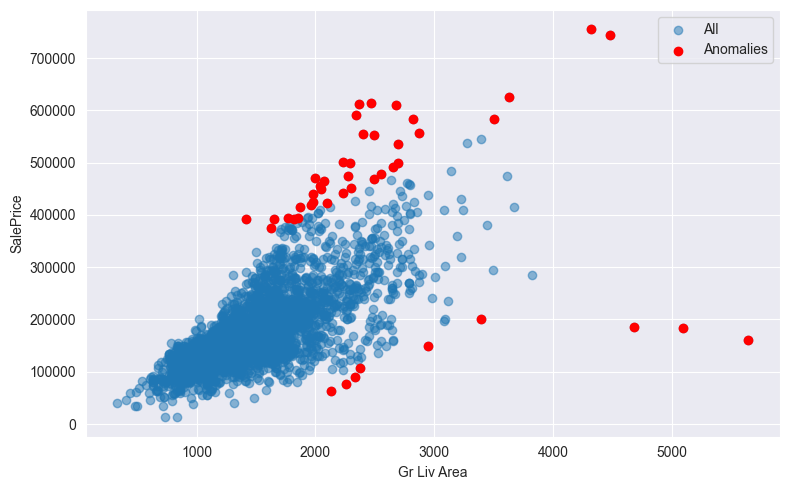

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(data["Gr Liv Area"], data["SalePrice"], alpha=0.5, label="All")
plt.scatter(anomalies["Gr Liv Area"], anomalies["SalePrice"], color="red", label="Anomalies")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Сравнение r2 score до и после удаления аномалий

In [34]:
def model_score(x, y):
    X_tr, X_te, y_tr, y_te = train_test_split(x, y, test_size=0.2)
    model = Ridge(alpha=1.0)
    model.fit(X_tr, y_tr)
    y_prediction = model.predict(X_te)
    r2 = r2_score(y_te, y_prediction)
    return r2

In [35]:
r2_before = model_score(X_scaled, y)
print(f"r2 до удаления: {r2_before:.3f}")

anomaly_indices = anomalies.index
X_cleared = np.delete(X_scaled, anomaly_indices, axis=0)
y_cleared = y.drop(anomaly_indices)
r2_after = model_score(X_cleared, y_cleared)
print(f"r2 после удаления: {r2_after:.3f}")
print(f"Разница в r2: {r2_after - r2_before:.3f}")

r2 до удаления: 0.903
r2 после удаления: 0.928
Разница в r2: 0.025


## 8. Сегментация объектов недвижимости на 5 групп
Используем KMeans

In [36]:
segments = ["Gr Liv Area", "Lot Area", "Overall Qual", "Overall Cond", "Year Built", "Total Bsmt SF", "Garage Area"]
X_seg = data[segments].fillna(0)
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

kmeans = KMeans(n_clusters=5, n_init=10)
data["Segment"] = kmeans.fit_predict(X_seg_scaled)
print(data["Segment"].value_counts().sort_index())

Segment
0     447
1    1051
2     636
3       4
4     792
Name: count, dtype: int64


## 9. PCA на всех числовых признаках + регрессия

In [37]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

Xpca_train, Xpca_test, ypca_train, ypca_test = train_test_split(X_pca, y, test_size=0.2)
pca_model = LinearRegression()
pca_model.fit(Xpca_train, ypca_train)
ypca_pred = pca_model.predict(Xpca_test)
print(f"PCA Regression: r2 = {r2_score(ypca_test, ypca_pred):.4f}")

PCA Regression: r2 = 0.5671


## 8. Динамика цен: годы, месяца, кризис 2008, сезонность(весна, зима)

Средняя цена по годам: Yr Sold
2006    181762.0
2007    185138.0
2008    178842.0
2009    181405.0
2010    172598.0
Name: SalePrice, dtype: float64


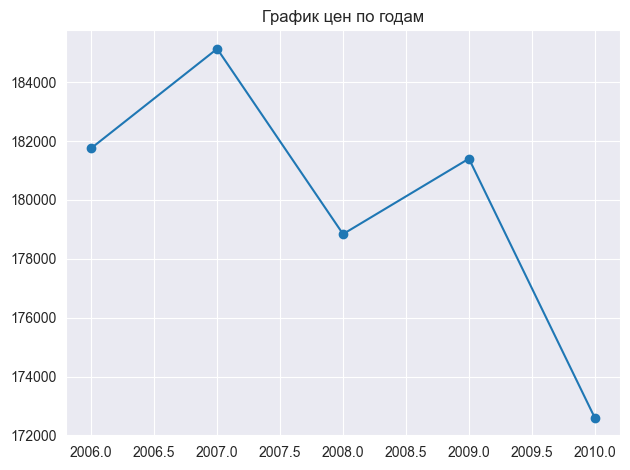

In [38]:
yearly = data.groupby("Yr Sold")["SalePrice"].mean()
print("Средняя цена по годам:", yearly.round(0))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("График цен по годам")
plt.tight_layout()
plt.show()

Средняя цена по месяцам: Mo Sold
1     194210.0
2     178364.0
3     176130.0
4     167712.0
5     173700.0
6     181543.0
7     184367.0
8     186222.0
9     191552.0
10    180057.0
11    187651.0
12    184454.0
Name: SalePrice, dtype: float64


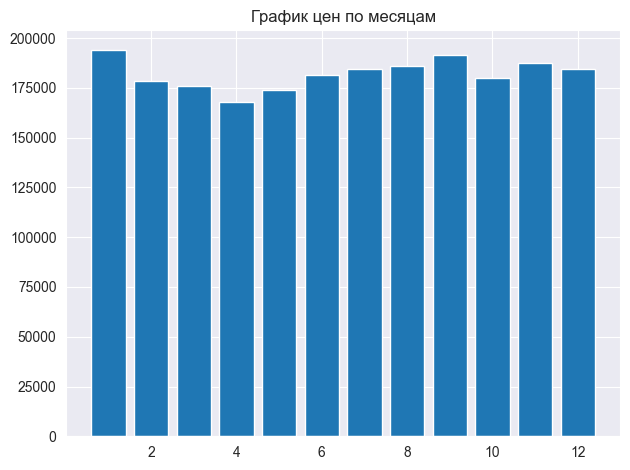

In [39]:
monthly = data.groupby("Mo Sold")["SalePrice"].mean()
print("Средняя цена по месяцам:", monthly.round(0))
plt.bar(monthly.index, monthly.values)
plt.title("График цен по месяцам")
plt.tight_layout()
plt.show()

In [40]:
mean2007 = data[data["Yr Sold"] == 2007]["SalePrice"].mean()
mean2009 = data[data["Yr Sold"] == 2009]["SalePrice"].mean()
drop = (mean2009 - mean2007) / mean2007 * 100
print(f"Кризис 2008 {drop:.2f}%")

Кризис 2008 -2.02%


In [41]:
winter = data[data["Mo Sold"].isin([12, 1, 2])]["SalePrice"].mean()
spring = data[data["Mo Sold"].isin([3, 4, 5])]["SalePrice"].mean()
season_diff = (spring - winter) / winter * 100
print(f"Цена весной выше цены зимой на {season_diff:.2f}%")

Цена весной выше цены зимой на -7.04%
